In [33]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expi
from scipy.fft import fft,ifft,fft2, ifft2, fftfreq, fftshift, ifftshift

# Given constants
xc = 0.5
yc = 0.5
sigma = 0.05

# Set up grid
N = 64
h = 1/N
x = np.linspace(0,1,N)
y = np.linspace(0,1,N)


# Define functions
def rho(x_i, y_i):
    C = 2*np.pi*sigma**2
    arg = -1/(2*sigma**2) * ((x_i - xc)**2 + (y_i - yc)**2)
    return 1/C * np.exp(arg)

def G(x_i, y_i):
    return -1/(4*np.pi) * np.log( x_i**2 + y_i**2 + h**2 )

def inf_norm(Vh, V):
    errs = np.zeros_like(V)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            errs[i][j] = np.abs(Vh[i][j] - V[i][j])
    return np.amax(errs)

In [14]:
# METHOD 0: Exact solution
V0 = np.zeros([N,N])
for i in range(N):
    x_i = x[i]
    for j in range(N):
        y_j = y[j]
        arg = ( (x_i - xc)**2 + (y_j - yc)**2 + h**2)/(2*sigma**2)
        V0[i][j] = -1/(4*np.pi) * ( expi(arg) + np.log( (x_i - xc)**2 + (y_j - yc)**2 + h**2) )

print('Method 0 complete.')

Method 0 complete.


In [10]:
# METHOD 1: Direct integration
V1 = np.zeros([N,N])
for i in range(N):
    x_i = x[i]
    for j in range(N):
        y_j = y[j]
        for ip in range(N):
            x_ip = x[ip] 
            for jp in range(N):
                y_jp = y[jp]
                V1[i][j] += rho(x_ip,y_jp) * G(x_i - x_ip, y_j - y_jp)
        V1[i][j] = h**2 * V1[i][j]

print('Method 1 complete.')

Complete.


In [31]:
# METHOD 2: Fourier method
V2 = np.zeros([N,N])
V2_hat = np.zeros([N,N])
rho_ = np.zeros([N,N])
G_ = np.zeros([N,N])

x_fft = fftfreq(N)
x_fft = fftshift(x_fft) + 0.5
y_fft = x_fft
for i in range(N):
    x_i = x_fft[i]
    for j in range(N):
        y_j = y_fft[j]
        rho_[i][j] = rho(x_i,y_j)
        G_[i][j] = G(x_i,y_j)

k = fftfreq(N)*2*np.pi/h
k = fftshift(k)
rho_hat = fft2(rho_)
rho_hat = fftshift(rho_hat)
G_hat = fft2(G_)
G_hat = fftshift(G_hat)

for i in range(N):
    for j in range(N):
        V2_hat[i][j] = rho_hat[i][j] * G_hat[i][j]

V2 = np.real(ifft2(V2_hat))

/tmp/ipykernel_2374787/2992173061.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  V2_hat[i][j] = rho_hat[i][j] * G_hat[i][j]


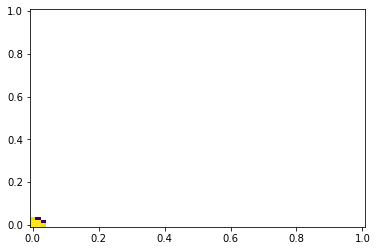

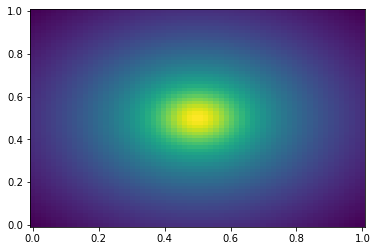

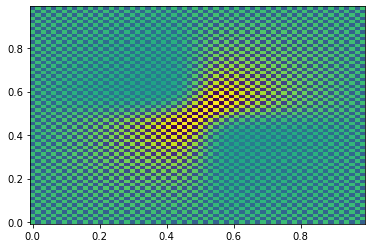

In [34]:
plt.figure()
plt.pcolormesh(x,y, V0, shading='auto')

plt.figure()
plt.pcolormesh(x,y, V1, shading='auto')

plt.figure()
plt.pcolormesh(x_fft,y_fft, V2, shading='auto')

plt.show()

In [ ]:
err_h = inf_norm(V1, V0)